In [ ]:
# %% [CELL 1] --- Install / import libraries -----------------------------------
# Kaggle already has torch, torchvision, pandas, sklearn, openpyxl pre-installed.
# We only need to add: timm (pretrained EfficientNet weights) and albumentations
# (for image augmentation) and optuna (for hyperparameter tuning).
 
!pip install -q timm albumentations optuna
 
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
 
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
 
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
 
import optuna
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
 
# WHY: timm gives us ImageNet-pretrained EfficientNet-B0 with one line of code.
# albumentations is faster and more flexible than torchvision transforms for
# domain-specific augmentation (soil images: lighting/angle variation matters).
# optuna automates hyperparameter search instead of manual trial and error.
 

In [2]:
# %% [CELL 1] --- Install / import libraries -----------------------------------
!pip install -q "huggingface_hub==0.24.6" timm albumentations optuna

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

import optuna

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# %% [CELL 2] --- EXPLORE the raw files first (do not skip this) --------------
BASE_DIR = "/kaggle/input/datasets/karimakanu/tensiometer-dataset/499_soil_Dataset"
IMAGE_DIR = os.path.join(BASE_DIR, "image")
META_PATH = os.path.join(BASE_DIR, "TraceData.xlsx")
META_PATH_2 = os.path.join(BASE_DIR, "trace_deta_analysis.xlsx")  # secondary file, inspect too
 
print("Number of image files found:", len(glob.glob(os.path.join(IMAGE_DIR, "*"))))
print("Example filenames:", glob.glob(os.path.join(IMAGE_DIR, "*"))[:5])
 
df_meta = pd.read_excel(META_PATH)
print("\n--- TraceData.xlsx ---")
print("Shape:", df_meta.shape)
print("Columns:", list(df_meta.columns))
print(df_meta.head())
 
df_meta2 = pd.read_excel(META_PATH_2)
print("\n--- trace_deta_analysis.xlsx ---")
print("Shape:", df_meta2.shape)
print("Columns:", list(df_meta2.columns))
print(df_meta2.head())

Number of image files found: 722
Example filenames: ['/kaggle/input/datasets/karimakanu/tensiometer-dataset/499_soil_Dataset/image/P0302_20Kpa.jpg', '/kaggle/input/datasets/karimakanu/tensiometer-dataset/499_soil_Dataset/image/P0689_8Kpa.jpg', '/kaggle/input/datasets/karimakanu/tensiometer-dataset/499_soil_Dataset/image/P0671_5Kpa.jpg', '/kaggle/input/datasets/karimakanu/tensiometer-dataset/499_soil_Dataset/image/P0284_20Kpa.jpg', '/kaggle/input/datasets/karimakanu/tensiometer-dataset/499_soil_Dataset/image/P0642_14Kpa.jpg']

--- TraceData.xlsx ---
Shape: (722, 12)
Columns: ['ID', 'FILE_NAME', 'Kpa', 'LAND_TYPE', 'SOIL_TYPE', 'LAST_IRREG/RAIN_DATE', 'LAST_IRREG/RAIN_TIME', 'CROPS_NAME', 'GROWTH_STAGE', 'DATE', 'TIME', 'Locatio']
       ID           FILE_NAME    Kpa LAND_TYPE SOIL_TYPE LAST_IRREG/RAIN_DATE  \
0  id0001      P0001_8Kpa.jpg   8.00      High     Doash           29/05/2026   
1  id0002     P0002_11Kpa.jpg  11.00      High     Doash           29/05/2026   
2  id0003     P000

In [4]:
# %% [CELL 3] --- CONFIG (confirmed against your real TraceData.xlsx columns) --
CONFIG = {
    "id_col": "ID",                  # e.g. "id0001" — kept for reference/joins
    "file_name_col": "FILE_NAME",    # e.g. "P0001_8Kpa.jpg" — used to locate the image on disk
    "target_col": "Kpa",             # continuous regression target
    "cat_cols": ["LAND_TYPE", "SOIL_TYPE", "CROPS_NAME", "GROWTH_STAGE"],
    "location_col": "Locatio",       # may be sparsely populated — checked in Cell 4
    "img_size": 224,
    "batch_size": 16,
    "n_folds": 5,
    "seed": 42,
    "epochs_head": 5,       # epochs training only the new head (backbone frozen)
    "epochs_finetune": 15,  # epochs fine-tuning unfrozen backbone
}
 
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

In [5]:
# %% [CELL 4] --- Build image_path <-> metadata table, and CHECK DATA LEAKAGE -
def build_dataframe(df_meta, image_dir, config):
    df = df_meta.copy()
 
    # FILE_NAME is an exact match to files on disk (e.g. "P0001_8Kpa.jpg"),
    # unlike ID ("id0001"), so we join on that directly instead of globbing.
    df["image_path"] = df[config["file_name_col"]].apply(
        lambda fn: os.path.join(image_dir, str(fn))
    )
    df["file_exists"] = df["image_path"].apply(os.path.isfile)
 
    n_missing = (~df["file_exists"]).sum()
    print(f"Rows with no matching image file: {n_missing} / {len(df)}")
    if n_missing > 0:
        print("Example missing filenames:", df.loc[~df["file_exists"], config["file_name_col"]].head(10).tolist())
    df = df[df["file_exists"]].drop(columns=["file_exists"]).reset_index(drop=True)
 
    return df
 
df = build_dataframe(df_meta, IMAGE_DIR, CONFIG)
 
# --- DATA LEAKAGE CHECKS ---
print("\n=== DATA LEAKAGE / QUALITY CHECKS ===")
 
# 1. Exact duplicate images (same file content) -> would leak across train/val
import hashlib
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
 
df["img_hash"] = df["image_path"].apply(file_hash)
dupe_count = df["img_hash"].duplicated().sum()
print(f"Duplicate images (identical files): {dupe_count}")
if dupe_count > 0:
    print("WARNING: duplicate images found. Keeping only first occurrence.")
    df = df.drop_duplicates(subset="img_hash").reset_index(drop=True)
 
# 2. Duplicate metadata rows (same ID appearing twice)
id_dupe = df[CONFIG["id_col"]].duplicated().sum()
print(f"Duplicate IDs in metadata: {id_dupe}")
 
# 3. Missing target / missing categorical values
print(f"Missing target values: {df[CONFIG['target_col']].isna().sum()}")
for c in CONFIG["cat_cols"]:
    print(f"Missing '{c}': {df[c].isna().sum()}")
df = df.dropna(subset=[CONFIG["target_col"]] + CONFIG["cat_cols"]).reset_index(drop=True)
 
# 4. Check whether the Location column is usable for group-safe splitting.
loc_col = CONFIG["location_col"]
n_populated = df[loc_col].notna().sum()
n_unique = df[loc_col].nunique(dropna=True)
print(f"'{loc_col}' populated: {n_populated}/{len(df)} rows, {n_unique} unique values")
 
if n_populated == len(df) and n_unique >= CONFIG["n_folds"]:
    USE_GROUP_KFOLD = True
    print("-> Location fully populated: will use GroupKFold (leakage-safe).")
elif n_populated > 0:
    USE_GROUP_KFOLD = False
    print(f"-> WARNING: '{loc_col}' only partially filled ({n_populated}/{len(df)}).")
    print("   Falling back to StratifiedKFold. You MUST disclose this gap")
    print("   as a limitation: some plots/fields may appear in both train and val.")
else:
    USE_GROUP_KFOLD = False
    print(f"-> '{loc_col}' is empty for all rows. Using StratifiedKFold only.")
    print("   Disclose in your paper: location-based leakage could not be checked.")
 
print(f"\nFinal usable dataset size: {len(df)} rows")
df.head()

Rows with no matching image file: 0 / 722

=== DATA LEAKAGE / QUALITY CHECKS ===
Duplicate images (identical files): 29
Duplicate IDs in metadata: 0
Missing target values: 0
Missing 'LAND_TYPE': 0
Missing 'SOIL_TYPE': 0
Missing 'CROPS_NAME': 0
Missing 'GROWTH_STAGE': 0
'Locatio' populated: 0/693 rows, 0 unique values
-> 'Locatio' is empty for all rows. Using StratifiedKFold only.
   Disclose in your paper: location-based leakage could not be checked.

Final usable dataset size: 693 rows


,ID,FILE_NAME,Kpa,LAND_TYPE,SOIL_TYPE,LAST_IRREG/RAIN_DATE,LAST_IRREG/RAIN_TIME,CROPS_NAME,GROWTH_STAGE,DATE,TIME,Locatio,image_path,img_hash
0,id0001,P0001_8Kpa.jpg,8.00,High,Doash,29/05/2026,16:00:00,Turmeric,Mature,NaN,NaN,NaN,/kaggle/input/datasets/karimakanu/tensiometer-...,7b2c6db120df5b8a0e57c8df5d761ae8
1,id0002,P0002_11Kpa.jpg,11.00,High,Doash,29/05/2026,16:00:00,Lechee,Mature,NaN,NaN,NaN,/kaggle/input/datasets/karimakanu/tensiometer-...,991c9d6d6e99d946d90fa286bf5bacb5
2,id0003,P0003_11Kpa.jpg,11.00,High,Doash,29/05/2026,16:00:00,Mango,Mature,NaN,NaN,NaN,/kaggle/input/datasets/karimakanu/tensiometer-...,cde769ff6ab6b8617125993e07a35273
3,id0004,P0004_15.25Kpa.jpg,15.25,High,Doash,29/05/2026,16:00:00,Betel_Nut,Mature,NaN,NaN,NaN,/kaggle/input/datasets/karimakanu/tensiometer-...,efffc5ad967633e9b563413e480d5357
4,id0006,P0006_20Kpa.jpg,20.00,High,Doash,29/05/2026,16:00:00,Betel_Nut,Mature,NaN,NaN,NaN,/kaggle/input/datasets/karimakanu/tensiometer-...,43203f6ca2af327fc37b86fcf14b7c52


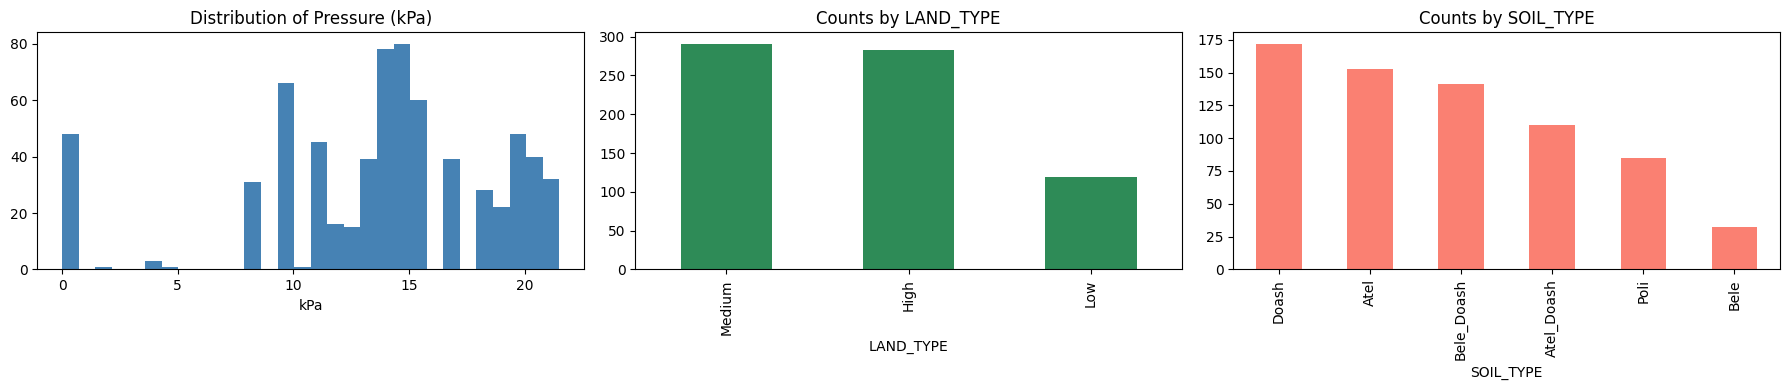

In [6]:
# %% [CELL 5] --- Exploratory Data Analysis (EDA) ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
 
axes[0].hist(df[CONFIG["target_col"]], bins=30, color="steelblue")
axes[0].set_title("Distribution of Pressure (kPa)")
axes[0].set_xlabel("kPa")
 
df[CONFIG["cat_cols"][0]].value_counts().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title(f"Counts by {CONFIG['cat_cols'][0]}")
 
df[CONFIG["cat_cols"][1]].value_counts().plot(kind="bar", ax=axes[2], color="salmon")
axes[2].set_title(f"Counts by {CONFIG['cat_cols'][1]}")
 
plt.tight_layout()
plt.show()

In [7]:
# %% [CELL 6] --- K-Fold split: GroupKFold if location is usable, else Stratified
# We bin the continuous kPa target into ~10 quantile bins purely so each fold
# gets a similar SPREAD of pressure values. The model itself still trains on
# the raw continuous value, not the bin.
df["pressure_bin"] = pd.qcut(df[CONFIG["target_col"]], q=10, duplicates="drop", labels=False)
 
df["fold"] = -1
if USE_GROUP_KFOLD:
    gkf = GroupKFold(n_splits=CONFIG["n_folds"])
    for fold, (_, val_idx) in enumerate(gkf.split(df, groups=df[CONFIG["location_col"]])):
        df.loc[val_idx, "fold"] = fold
    print("Used GroupKFold on location — no plot appears in both train and val.")
else:
    skf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True, random_state=CONFIG["seed"])
    for fold, (_, val_idx) in enumerate(skf.split(df, df["pressure_bin"])):
        df.loc[val_idx, "fold"] = fold
    print("Used StratifiedKFold on pressure bins (location not usable for grouping).")
 
print(df.groupby("fold")[CONFIG["target_col"]].agg(["count", "mean", "std"]))
# Check: mean/std of kPa should look similar across all folds. If one fold's
# mean is wildly different, your stratification isn't working correctly.
 

Used StratifiedKFold on pressure bins (location not usable for grouping).
      count       mean       std
fold                            
0       139  13.596403  5.576359
1       139  13.860432  5.221359
2       139  13.766906  5.266542
3       138  13.852899  5.381846
4       138  13.995290  4.897832


In [8]:
# %% [CELL 7] --- Encode categorical metadata (for the fusion-ready dataset) ---
encoders = {}
for c in CONFIG["cat_cols"]:
    le = LabelEncoder()
    df[c + "_enc"] = le.fit_transform(df[c].astype(str))
    encoders[c] = le
    print(f"{c}: {len(le.classes_)} unique classes")

LAND_TYPE: 3 unique classes
SOIL_TYPE: 6 unique classes
CROPS_NAME: 14 unique classes
GROWTH_STAGE: 8 unique classes


In [29]:
# %% [CELL 9] --- PyTorch Dataset class -----------------------------------------
class SoilDataset(Dataset):
    def __init__(self, dataframe, target_col, transform):
        self.df = dataframe.reset_index(drop=True)
        self.target_col = target_col
        self.transform = transform
        
 
    def __len__(self):
        return len(self.df)
        
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image=image)["image"]
        target = torch.tensor(row[self.target_col], dtype=torch.float32)
        return image, target
        

ds = SoilDataset(df, CONFIG["target_col"], val_transform)
img, target = ds[0]
print(img.shape, target)


torch.Size([3, 224, 224]) tensor(8.)


In [30]:
# %% [CELL 10] --- Model: EfficientNet-B0 with a regression head ---------------
class EffNetRegressor(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # pretrained=True loads ImageNet weights; num_classes=0 strips the
        # original classification head and returns raw pooled features.
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        n_features = self.backbone.num_features  # 1280 for EfficientNet-B0
        self.head = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),  # single continuous output = predicted kPa
        )
 
    def forward(self, x):
        feats = self.backbone(x)
        out = self.head(feats)
        return out.squeeze(1)
 
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
 
    def unfreeze_last_blocks(self, n_blocks=2):
        # Unfreeze only the last n blocks of the backbone for fine-tuning,
        # rather than the whole network — safer for a small dataset.
        blocks = list(self.backbone.blocks)
        for block in blocks[-n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True

model = EffNetRegressor().to(device)
print(sum(p.numel() for p in model.parameters()), "total params")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

4171645 total params


In [31]:
# %% [CELL 11] --- Train / evaluate functions for ONE fold ---------------------
def train_one_fold(train_df, val_df, config, lr_head=1e-3, lr_finetune=1e-5, weight_decay=1e-4):
    train_ds = SoilDataset(train_df, config["target_col"], train_transform)
    val_ds = SoilDataset(val_df, config["target_col"], val_transform)
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False, num_workers=2)
 
    model = EffNetRegressor().to(device)
    criterion = nn.SmoothL1Loss()  # Huber loss: more robust to outlier kPa readings than plain MSE
 
    # --- Stage 1: train only the head, backbone frozen ---
    model.freeze_backbone()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=lr_head, weight_decay=weight_decay)
    for epoch in range(config["epochs_head"]):
        model.train()
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()
 
    # --- Stage 2: unfreeze last blocks, fine-tune with low LR ---
    model.unfreeze_last_blocks(n_blocks=2)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=lr_finetune, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs_finetune"])
 
    best_val_rmse = float("inf")
    best_state = None
    patience, patience_counter = 5, 0
 
    for epoch in range(config["epochs_finetune"]):
        model.train()
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, targets)
            loss.backward()
            optimizer.step()
        scheduler.step()
 
        val_rmse, val_mae, val_r2, _, _ = evaluate(model, val_loader)
        print(f"  epoch {epoch+1}/{config['epochs_finetune']} | val RMSE={val_rmse:.3f} MAE={val_mae:.3f} R2={val_r2:.3f}")
 
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("  Early stopping (no improvement).")
                break
 
    model.load_state_dict(best_state)
    return model, best_val_rmse
 
 
def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.numpy())
    all_preds, all_targets = np.array(all_preds), np.array(all_targets)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    return rmse, mae, r2, all_preds, all_targets

In [32]:
# %% [CELL 12] --- Hyperparameter tuning with Optuna (small search, ONE fold) --
# WHY only one fold for tuning: running full 5-fold CV per trial is too slow
# on Kaggle's free GPU quota. We tune on fold 0, then use the best found
# hyperparameters to train the final full 5-fold cross-validation in CELL 13.
 
def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 5e-3, log=True)
    lr_finetune = trial.suggest_float("lr_finetune", 1e-6, 5e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
 
    train_df = df[df["fold"] != 0].reset_index(drop=True)
    val_df = df[df["fold"] == 0].reset_index(drop=True)
 
    small_config = dict(CONFIG)
    small_config["epochs_head"] = 3
    small_config["epochs_finetune"] = 6  # short runs during search only
 
    _, val_rmse = train_one_fold(train_df, val_df, small_config,
                                  lr_head=lr_head, lr_finetune=lr_finetune,
                                  weight_decay=weight_decay)
    return val_rmse
 
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)  # increase n_trials if you have GPU time budget
 
print("Best hyperparameters found:", study.best_params)
best_params = study.best_params
 

[I 2026-08-14 14:05:09,964] A new study created in memory with name: no-name-48e14c6d-4ac4-4660-8fed-33f7c85deaf4


  epoch 1/6 | val RMSE=5.850 MAE=4.664 R2=-0.109
  epoch 2/6 | val RMSE=5.408 MAE=4.311 R2=0.053
  epoch 3/6 | val RMSE=4.885 MAE=3.825 R2=0.227
  epoch 4/6 | val RMSE=4.771 MAE=3.754 R2=0.263
  epoch 5/6 | val RMSE=4.689 MAE=3.746 R2=0.288


[I 2026-08-14 14:06:26,250] Trial 0 finished with value: 4.689152947493847 and parameters: {'lr_head': 0.0009156990567682121, 'lr_finetune': 4.9766817145450986e-05, 'weight_decay': 1.1010420727767944e-05}. Best is trial 0 with value: 4.689152947493847.


  epoch 6/6 | val RMSE=4.807 MAE=3.776 R2=0.251
  epoch 1/6 | val RMSE=6.617 MAE=5.481 R2=-0.418
  epoch 2/6 | val RMSE=5.855 MAE=4.555 R2=-0.110
  epoch 3/6 | val RMSE=5.402 MAE=4.246 R2=0.055
  epoch 4/6 | val RMSE=5.026 MAE=3.895 R2=0.182
  epoch 5/6 | val RMSE=5.108 MAE=4.022 R2=0.155


[I 2026-08-14 14:07:40,263] Trial 1 finished with value: 4.880806814630462 and parameters: {'lr_head': 0.0007093546495606149, 'lr_finetune': 4.1998694455442404e-05, 'weight_decay': 3.49357867013378e-05}. Best is trial 0 with value: 4.689152947493847.


...

  epoch 6/6 | val RMSE=4.837 MAE=3.747 R2=0.242
  epoch 1/6 | val RMSE=6.082 MAE=4.923 R2=-0.198
  epoch 2/6 | val RMSE=5.694 MAE=4.572 R2=-0.050
  epoch 3/6 | val RMSE=5.575 MAE=4.441 R2=-0.007
  epoch 4/6 | val RMSE=5.645 MAE=4.581 R2=-0.032
  epoch 5/6 | val RMSE=5.521 MAE=4.408 R2=0.013


[I 2026-08-14 14:22:11,790] Trial 13 finished with value: 5.520938032585002 and parameters: {'lr_head': 0.002196851229819232, 'lr_finetune': 1.3637761876887594e-05, 'weight_decay': 1.0485176574534247e-05}. Best is trial 0 with value: 4.689152947493847.


  epoch 6/6 | val RMSE=5.600 MAE=4.493 R2=-0.016
  epoch 1/6 | val RMSE=6.094 MAE=4.987 R2=-0.203
  epoch 2/6 | val RMSE=5.889 MAE=4.801 R2=-0.123
  epoch 3/6 | val RMSE=5.733 MAE=4.652 R2=-0.065
  epoch 4/6 | val RMSE=5.677 MAE=4.605 R2=-0.044
  epoch 5/6 | val RMSE=5.685 MAE=4.639 R2=-0.047


[I 2026-08-14 14:23:24,079] Trial 14 finished with value: 5.676546049212331 and parameters: {'lr_head': 0.0023209972709687414, 'lr_finetune': 7.691301784967951e-06, 'weight_decay': 0.001601402410391601}. Best is trial 0 with value: 4.689152947493847.


  epoch 6/6 | val RMSE=5.860 MAE=4.796 R2=-0.112
Best hyperparameters found: {'lr_head': 0.0009156990567682121, 'lr_finetune': 4.9766817145450986e-05, 'weight_decay': 1.1010420727767944e-05}


In [33]:
# %% [CELL 13] --- FINAL: full 5-fold cross-validation with best hyperparameters
fold_results = []
oof_preds = np.zeros(len(df))  # out-of-fold predictions, for honest overall metrics
 
for fold in range(CONFIG["n_folds"]):
    print(f"\n===== FOLD {fold} =====")
    train_df = df[df["fold"] != fold].reset_index(drop=True)
    val_df = df[df["fold"] == fold].reset_index(drop=True)
 
    model, best_rmse = train_one_fold(
        train_df, val_df, CONFIG,
        lr_head=best_params["lr_head"],
        lr_finetune=best_params["lr_finetune"],
        weight_decay=best_params["weight_decay"],
    )
 
    val_loader = DataLoader(SoilDataset(val_df, CONFIG["target_col"], val_transform),
                             batch_size=CONFIG["batch_size"], shuffle=False)
    rmse, mae, r2, preds, targets = evaluate(model, val_loader)
    fold_results.append({"fold": fold, "rmse": rmse, "mae": mae, "r2": r2})
 
    oof_preds[df["fold"] == fold] = preds
    torch.save(model.state_dict(), f"/kaggle/working/effnetb0_fold{fold}.pt")
 
results_df = pd.DataFrame(fold_results)
print("\n=== PER-FOLD RESULTS ===")
print(results_df)
print("\n=== MEAN ± STD ACROSS FOLDS (report THIS in your paper) ===")
print(results_df[["rmse", "mae", "r2"]].agg(["mean", "std"]))
 


===== FOLD 0 =====
  epoch 1/15 | val RMSE=5.787 MAE=4.700 R2=-0.085
  epoch 2/15 | val RMSE=5.186 MAE=4.131 R2=0.129
  epoch 3/15 | val RMSE=4.738 MAE=3.695 R2=0.273
  epoch 4/15 | val RMSE=4.581 MAE=3.554 R2=0.320
  epoch 5/15 | val RMSE=4.453 MAE=3.462 R2=0.358
  epoch 6/15 | val RMSE=4.261 MAE=3.268 R2=0.412
  epoch 7/15 | val RMSE=4.105 MAE=3.115 R2=0.454
  epoch 8/15 | val RMSE=4.165 MAE=3.230 R2=0.438
  epoch 9/15 | val RMSE=4.063 MAE=3.075 R2=0.465
  epoch 10/15 | val RMSE=3.920 MAE=2.950 R2=0.502
  epoch 11/15 | val RMSE=4.172 MAE=3.151 R2=0.436
  epoch 12/15 | val RMSE=3.668 MAE=2.796 R2=0.564
  epoch 13/15 | val RMSE=3.945 MAE=2.985 R2=0.496
  epoch 14/15 | val RMSE=3.990 MAE=3.059 R2=0.484
  epoch 15/15 | val RMSE=3.847 MAE=2.936 R2=0.521

===== FOLD 1 =====
  epoch 1/15 | val RMSE=6.140 MAE=4.904 R2=-0.393
  epoch 2/15 | val RMSE=5.709 MAE=4.576 R2=-0.204
  epoch 3/15 | val RMSE=5.413 MAE=4.318 R2=-0.082
  epoch 4/15 | val RMSE=5.507 MAE=4.415 R2=-0.120
  epoch 5/15 | val

Overall OOF RMSE=4.093  MAE=3.195  R2=0.394

--- MAE by LAND_TYPE ---
LAND_TYPE
Low       3.066320
Medium    3.135347
High      3.309840
Name: abs_error, dtype: float64

--- MAE by SOIL_TYPE ---
SOIL_TYPE
Atel          2.980752
Poli          3.019972
Atel_Doash    3.121972
Doash         3.203143
Bele_Doash    3.413587
Bele          3.923022
Name: abs_error, dtype: float64

--- MAE by CROPS_NAME ---
CROPS_NAME
Lechee           1.893728
Okra             2.290869
Grass            2.909252
Maize            2.942686
Sponge Gourd     2.963399
Meheguni         2.999828
Rich             3.066320
No               3.070040
Eggplant         3.115265
Jute             3.140222
Lemon            4.085191
Mango            4.249762
Betel_Nut        4.371577
Turmeric        11.322683
Name: abs_error, dtype: float64

--- MAE by GROWTH_STAGE ---
GROWTH_STAGE
Post-Harvest        1.513743
Seedling            2.641426
Land_Preparation    2.702449
Post_Harvest        3.017681
Pre_hervest         3.197284
Matu

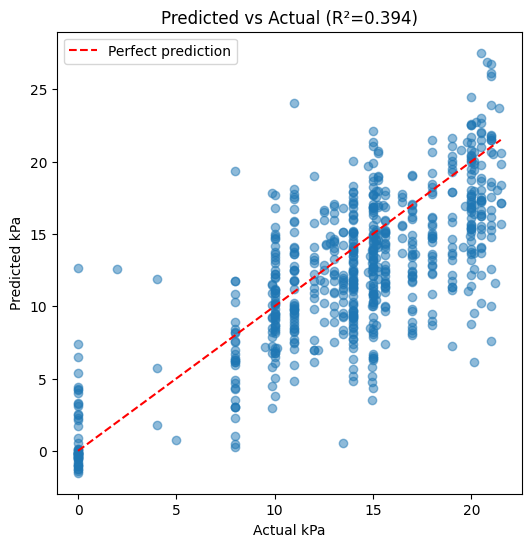

In [34]:
# %% [CELL 14] --- Overall out-of-fold metrics + breakdown by soil/land type ---
overall_rmse = np.sqrt(mean_squared_error(df[CONFIG["target_col"]], oof_preds))
overall_mae = mean_absolute_error(df[CONFIG["target_col"]], oof_preds)
overall_r2 = r2_score(df[CONFIG["target_col"]], oof_preds)
print(f"Overall OOF RMSE={overall_rmse:.3f}  MAE={overall_mae:.3f}  R2={overall_r2:.3f}")
 
df["oof_pred"] = oof_preds
df["abs_error"] = (df["oof_pred"] - df[CONFIG["target_col"]]).abs()
 
# Breakdown reviewers will ask for: does accuracy hold across all soil types?
for c in CONFIG["cat_cols"]:
    print(f"\n--- MAE by {c} ---")
    print(df.groupby(c)["abs_error"].mean().sort_values())
 
# Predicted vs Actual scatter plot — standard figure for a regression paper
plt.figure(figsize=(6, 6))
plt.scatter(df[CONFIG["target_col"]], df["oof_pred"], alpha=0.5)
lims = [df[CONFIG["target_col"]].min(), df[CONFIG["target_col"]].max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual kPa")
plt.ylabel("Predicted kPa")
plt.title(f"Predicted vs Actual (R²={overall_r2:.3f})")
plt.legend()
plt.savefig("/kaggle/working/pred_vs_actual.png", dpi=200)
plt.show()
 
df.to_csv("/kaggle/working/oof_predictions.csv", index=False)